<a href="https://colab.research.google.com/github/Saifuddin-Yasir/ML-AI-Learning-Journey/blob/main/ML_Mid_Term_Exam_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [ ]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler ,OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

**1. After calculating by code, we got median is 33 and IQR is 2.0**

**2. After using IQR rule ,we got 500 is an outliers. here ,we got IQR is 2.0 .here, q1 is 32 and q3 is 34.So, lower fence is 32-1.5*IQR= 29 and upper fences is 37. 50. all data is beyond in IQR fences. Hence,500, it's a outliers.**

**3. A big number outliers in dataset can impact on both mean and std which makes a model training wrong .it would predicts mostly wrong for the outliers which led down accuracy of a model. On the hand, a big numbers outliers can't change or affect on median and IQR, which helps to train a model well. So, we get good accuracy result.**

In [ ]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1_median=np.median(data_q1)
print("Median:", data_q1_median)
q1=np.quantile(data_q1, 0.25)
q3=np.quantile(data_q1, 0.75)
iqr=q3-q1
print("IQR:", iqr)
print("IQR fences:",q1-1.5*iqr,"to",q3+1.5*iqr)


Median: 33.0
IQR: 2.0
IQR fences: 29.0 to 37.0


### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)

_1. By using bayes theorem, we write the given result ...**P(D)=0.01** , **P(T+/D)=0.9** and **P(T-/-D)=0.92** . Now,**PPV=TP/(TP+FP)**...In bayes theorem **PPV** is **P(D+/T+)**.._

_Now, After calculation by theorem we got **PPV** is **0.102** ._

_2. If prevalence rise to 20% then **P(D)= 0.2** .After Calculations we got,PPV increses.it will be **0.737**...here, As patient increses the probability of positive predictive value will increase.._

_**bayes formula we used ,**
P(D+/T+)= (P(T+/D)*P(D)) / ((P(T+/D)*P(D)) + (P(T+/-D)*P(-D)))_

### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

_1. **Here, our target variable is premium_user which detects output is only two 0 and 1. so , it's classification type ML Task.**_

_2. **There are four steps of pre-processing of this dataset ..here are** -_


*   Detecting outliers & Handling missing values of age, region and daily_clicks columns.
*   transform categorical data to numerical data by encoding for region column.

*   Do scaling for numerical data for age and daily_clicks columns for better model train.
*  At last , split dataset as train and test where test is lower than train .Like, 80% train and 20% test.

_3. **At first , i would apply on preprocessing steps on given raw dataset.after getting processed and split dataset,i would fit this dataset's train data to a model algorithm like logistic algorithm ,decision tree etc.then, i will predict from the model by the test splited data .After that, we can check our result with target column test result to predicted result and can get Accuracy,recall,precision, & F1 score. it will show us the model efficiency and to decide whether we can rely on this model or not**._

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.

Missing Value Summary for each column
age             2
region          0
purchases       1
premium_user    0
dtype: int64
Unique Value of each column 
age             5
region          4
purchases       6
premium_user    2
dtype: int64
                age  purchases
age        1.000000   0.923677
purchases  0.923677   1.000000


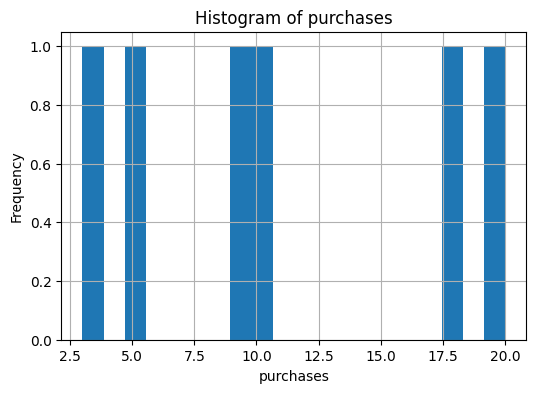

<BarContainer object of 4 artists>

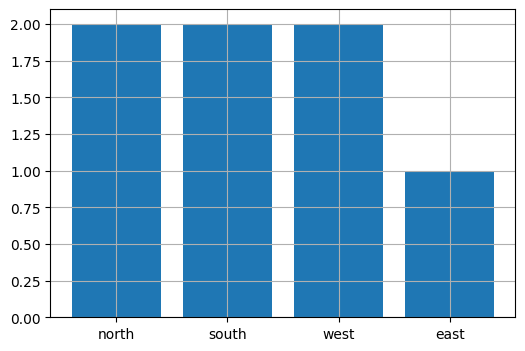

In [ ]:
# Q4 – Student Answer (1)

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
print("Missing Value Summary for each column")
print(df.isnull().sum())
print("Unique Value of each column ")
print(df.nunique())
print(df[["age","purchases"]].corr())
plt.hist(df["purchases"],bins=20)
plt.xlabel("purchases")
plt.ylabel("Frequency")
plt.title("Histogram of purchases")
plt.show()
plt.bar(df["region"].value_counts().index,df["region"].value_counts())

**Here, we compute number of missing value and unique value of dataset features.it's shown by print() function.then, we showed a correlation between "age" and "purchases" column where both have positive correlation about 0.92. then, we plot histogram by matplotlib function of "purchases" . lastly, we plot a barplot of "region" by valuecount() of their features.**

In [ ]:
# Q4 – Student Answer (2)

median=SimpleImputer(strategy="median")
df["age"]=median.fit_transform(df[['age']])

mean=SimpleImputer(strategy="mean")
df["purchases"]=mean.fit_transform(df[['purchases']]).astype(int)

one_hot=OneHotEncoder(sparse_output=False)
encoded=one_hot.fit_transform(df[["region"]])
encoded_df = pd.DataFrame(encoded, columns=one_hot.get_feature_names_out(["region"]))
df_encoded = pd.concat([df, encoded_df], axis=1)
df_encoded=df_encoded.drop("region",axis=1)

scaling=RobustScaler()
df_encoded[["age","purchases"]]=scaling.fit_transform(df_encoded[["age","purchases"]])
df_encoded


,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,-1.000000,0,0.0,1.0,0.0,0.0
1,0.0,0.000000,1,0.0,0.0,1.0,0.0
2,0.0,-0.714286,0,0.0,1.0,0.0,0.0
3,-0.8,0.000000,0,1.0,0.0,0.0,0.0
4,1.5,1.428571,1,0.0,0.0,0.0,1.0
5,2.2,1.142857,1,0.0,0.0,0.0,1.0
6,0.0,-0.142857,0,0.0,0.0,1.0,0.0


At first , we fill up missing value of age column by using median and puchases column by using mean. After that we encoded categorical column "region" by one-hot encoding. Then, we add this to main Dataset df. After that,we drop the categorical region column. At last, we scaled our numerical column "age" and "purchases" by robust scaling and showed final dataset df_encoded.

In [ ]:
# Q4 – Student Answer (3)

df_encoded["High_spender"] = pd.cut(df["purchases"],bins=[0,9,30],labels=[0,1])

**here, we make a domain driven features column "High_spender" in term of purchases column . here, we used binning to created this features and got 2 output as instruction . where, 0= No ,1= Yes**

In [ ]:
# Q4 – Student Answer (4)
df_encoded

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,-1.000000,0,0.0,1.0,0.0,0.0
1,0.0,0.000000,1,0.0,0.0,1.0,0.0
2,0.0,-0.714286,0,0.0,1.0,0.0,0.0
3,-0.8,0.000000,0,1.0,0.0,0.0,0.0
4,1.5,1.428571,1,0.0,0.0,0.0,1.0
5,2.2,1.142857,1,0.0,0.0,0.0,1.0
6,0.0,-0.142857,0,0.0,0.0,1.0,0.0


**Finally, we showed our final dataset df_encoded , which is ready for the train model.**

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [ ]:
# Q5 – Student Answer (1)

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

,area_sqft,bedrooms,price
0,800,2,120
1,1000,2,150
2,1200,3,170
3,1500,3,210
4,1800,4,260
5,2000,4,300


**Here, we showed our created dataset df2....**

In [ ]:
# Q5 – Student Answer (2)

x=df2[["area_sqft","bedrooms"]]
y=df2["price"]
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)


**Then, we split in train test by 80/20 of x and y..where x= features and y= target variable...**

In [ ]:
# Q5 – Student Answer (3)

model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

**Here, we fitted linear regression by train dataset (x_train,y_train)..**

In [ ]:
# Q5 – Student Answer (4)

print("Intercept:",model.intercept_)
print("Coefficients:",model.coef_)
y_pred=model.predict(x_test)
print("Predictions:",y_pred)

Intercept: -33.84615384615387
Coefficients: [0.15384615 5.38461538]
Predictions: [100.         130.76923077]


**Here, we printed in intercept and co-efficient of our linear regression model after training.. Also, we predict test result of x by this model..**

In [ ]:
# Q5 – Student Answer (5)

MAE=mean_absolute_error(y_test,y_pred)
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
R2=r2_score(y_test,y_pred)
print("MSE : ",MAE)
print("RMSE : ",RMSE)
print("R squared: ",R2)

MSE :  19.615384615384613
RMSE :  19.61915499208746
R squared:  -0.7107166337935567


**After that, we calculate MAE,RMSE,R2 by using ready function . here, MSE and RMSE is quietly near and almost equal..**

Text(0.5, 1.0, 'Residual Plot')

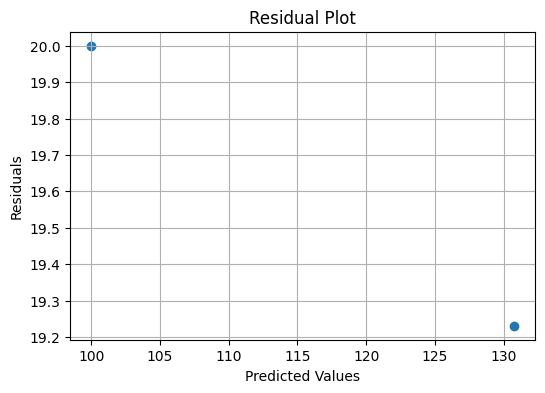

In [ ]:
# Q5 – Student Answer (6)

residual=y_test-y_pred
plt.scatter(y_pred,residual)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

**Here, we plot residual plot as instructed in question . we plot y_pred is x direction and residual = y_test-y_pred in y direction....**

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [ ]:
# Q6 – Student Answer (1)

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
y_pred= (y_prob>=0.5).astype(int)

# Write your code for threshold 0.5
C_Matrix = confusion_matrix(y_true,y_pred)
prec = precision_score(y_true,y_pred)
rec = recall_score(y_true,y_pred)
f1 = f1_score(y_true,y_pred)

print('Confusion Matrix:',C_Matrix)
print('Precision:',prec)
print('Recall   :',rec)
print('F1 score :',f1)

[1 0 1 0 1 0 1 0 1 0]
Confusion Matrix: [[5 0]
 [0 5]]
Precision: 1.0
Recall   : 1.0
F1 score : 1.0


**At first , we set our threshold 0.5 in y_pred . after that, we use function of confusion matrix,precision ,recall and F1 score .then, we printed of these result..**


In [ ]:
# Q6 – Student Answer (2)

y_pred= (y_prob>=0.3).astype(int)

# Write your code for threshold 0.3
C_Matrix = confusion_matrix(y_true,y_pred)
prec = precision_score(y_true,y_pred)
rec = recall_score(y_true,y_pred)
f1 = f1_score(y_true,y_pred)

print('Confusion Matrix:',C_Matrix)
print('Precision:',prec)
print('Recall   :',rec)
print('F1 score :',f1)

Confusion Matrix: [[3 2]
 [0 5]]
Precision: 0.7142857142857143
Recall   : 1.0
F1 score : 0.8333333333333334


**After changing the threshold to 0.3 .. we again calculate confusion matrix,precision,recall and F1 score.**

**# Q6 – Student Answer (3)**

**Here, After lowering the threshold from 0.5 to 0.3, the y_pred also change for 0.3 to 0.5 value.So, in this 0.3 to 0.5 range value become predict 1. but,in our test result we got that are 0 which changes precision as well as F1 score.**

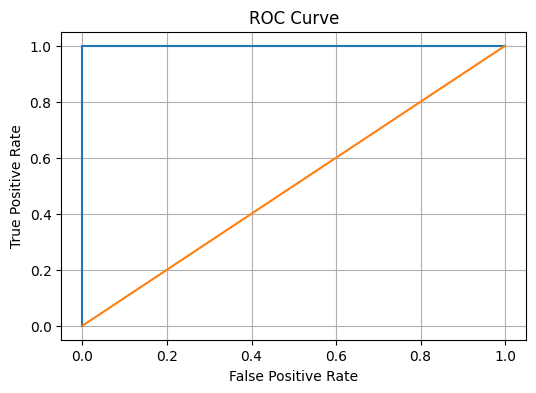

In [ ]:
# Q6 – Student Answer (4)

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


In [ ]:
# Q6 – Student Answer (5)

AUC=auc(fpr,tpr)
print("AUC:",round(AUC,3))

AUC: 1.0


**# Q6 – Student Answer (6)**

**AUC range is genarally 0 to 1 . high AUC means close to 1 which represent perfectly classify most of features. On the otherhand , low AUC means random guessing and sometimes predict inverse result...**

In [ ]:
# Q6 – Student Answer (7)

df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
model=DecisionTreeClassifier(max_depth=2)
x=df3[["hours"]]
y=df3["passed"]
model.fit(x,y)
model.predict(x)

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 1])

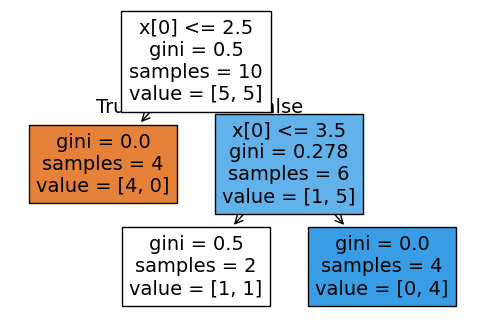

In [ ]:
# Q6 – Student Answer (8)

plot=plot_tree(model,filled=True)

**# Q6 – Student Answer (9)**

**Here, we fit hours and passed column data Decision tree classifier where we set max depth=2 as instructed. After fitted data to model we predict result .and plot plottree .The tree has a maximum depth of 2, which has small dataset of 10 samples. This limited depth prevents it from memorizing every point, so the tree is likely to generalize well...**
